In [7]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

In [8]:
def calculate_stochastic(data, k_period=14, d_period=3, overbought=80, oversold=20):
    """
    Calculate Stochastic Oscillator
    k_period: Look back period for %K
    d_period: Look back period for %D (simple moving average of %K)
    """
    # Calculate %K
    low_min = data['Low'].rolling(window=k_period).min()
    high_max = data['High'].rolling(window=k_period).max()
    
    data['%K'] = ((data['Close'] - low_min) / (high_max - low_min)) * 100
    
    # Calculate %D (3-period moving average of %K)
    data['%D'] = data['%K'].rolling(window=d_period).mean()
    
    # Generate signals
    data['Signal'] = 0  # 0 represents no signal
    
    # Buy signal: When both %K and %D are below oversold (20) and %K crosses above %D
    data.loc[(data['%K'] < oversold) & (data['%D'] < oversold) & 
            (data['%K'].shift(1) <= data['%D'].shift(1)) & 
            (data['%K'] > data['%D']), 'Signal'] = 1
    
    # Sell signal: When both %K and %D are above overbought (80) and %K crosses below %D
    data.loc[(data['%K'] > overbought) & (data['%D'] > overbought) & 
            (data['%K'].shift(1) >= data['%D'].shift(1)) & 
            (data['%K'] < data['%D']), 'Signal'] = -1
    
    return data

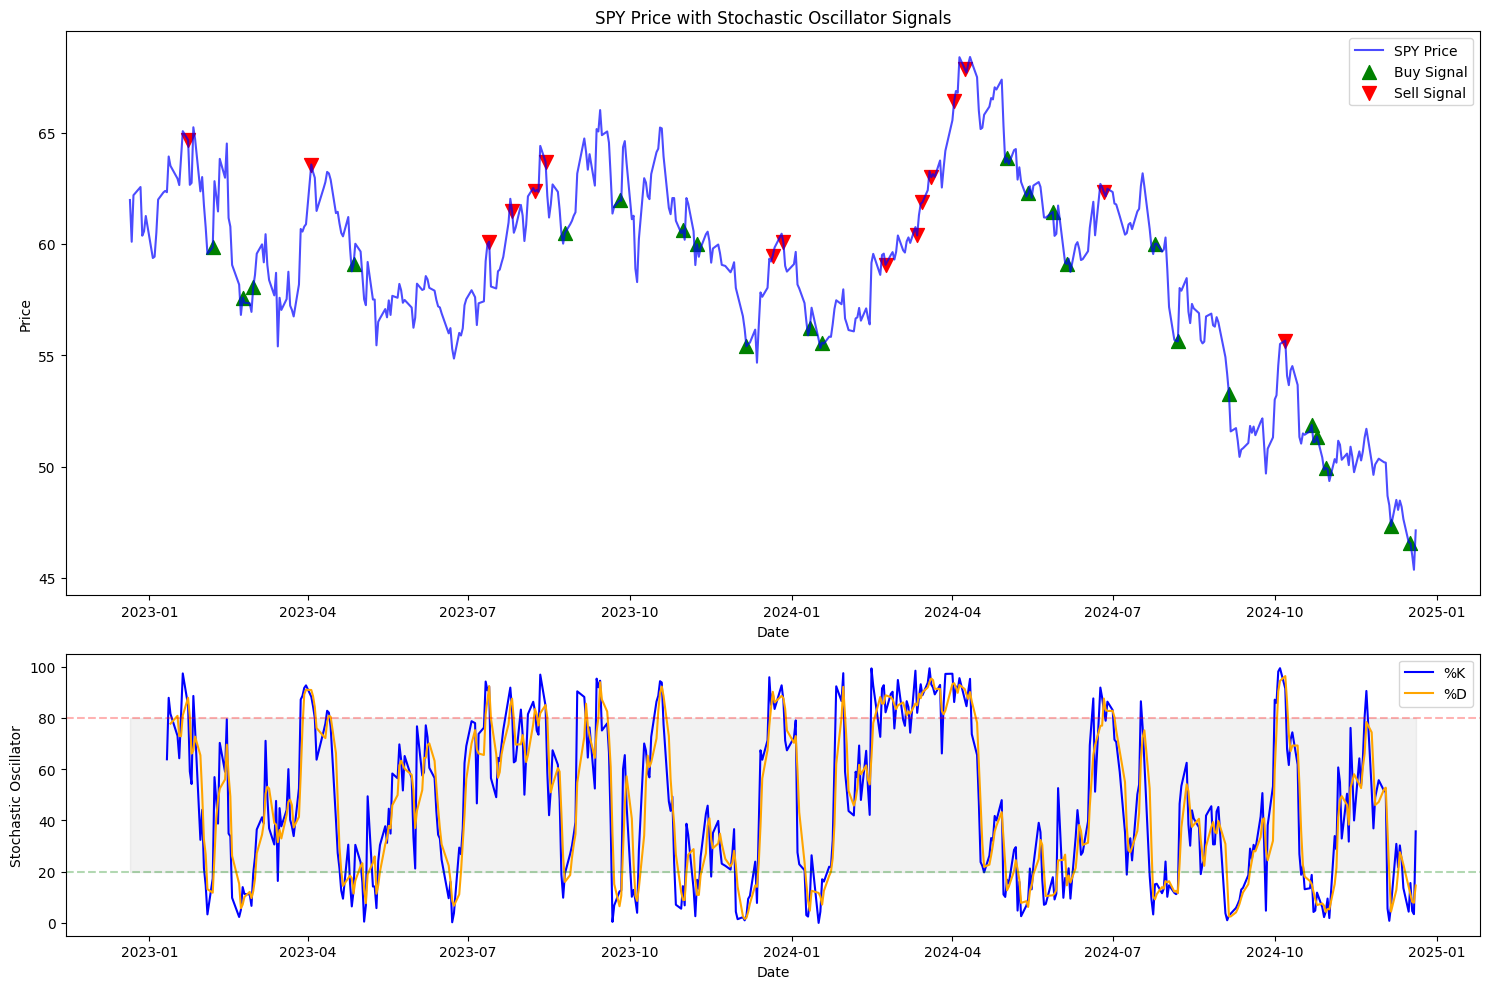


Recent Signals:
                               Close Signal_Type         %K         %D
Date                                                                  
2024-10-22 00:00:00-04:00  51.864735         BUY  18.703656  15.117223
2024-10-25 00:00:00-04:00  51.347088         BUY  11.807284   6.960451
2024-10-30 00:00:00-04:00  49.943451         BUY   4.519731   4.300825
2024-12-06 00:00:00-05:00  47.325329         BUY   6.896551   4.422438
2024-12-17 00:00:00-05:00  46.560001         BUY  15.556067  11.176002


In [ ]:
# Download SPY data
ticker_value = 'SPY'
ticker = yf.Ticker(ticker_value)
spy = ticker.history(period="2y")

# Apply Stochastic Oscillator
spy_data = calculate_stochastic(spy.copy())

# Create the visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), gridspec_kw={'height_ratios': [2, 1]})

# Plot price
ax1.plot(spy_data.index, spy_data['Close'], label='SPY Price', color='blue', alpha=0.7)
ax1.set_title('SPY Price with Stochastic Oscillator Signals')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price')

# Plot buy signals
buy_signals = spy_data[spy_data['Signal'] == 1]
ax1.scatter(buy_signals.index, buy_signals['Close'], 
           color='green', marker='^', s=100, label='Buy Signal')

# Plot sell signals
sell_signals = spy_data[spy_data['Signal'] == -1]
ax1.scatter(sell_signals.index, sell_signals['Close'], 
           color='red', marker='v', s=100, label='Sell Signal')

ax1.legend()

# Plot Stochastic Oscillator
ax2.plot(spy_data.index, spy_data['%K'], label='%K', color='blue')
ax2.plot(spy_data.index, spy_data['%D'], label='%D', color='orange')
ax2.axhline(y=80, color='r', linestyle='--', alpha=0.3)
ax2.axhline(y=20, color='g', linestyle='--', alpha=0.3)
ax2.fill_between(spy_data.index, 80, 20, color='gray', alpha=0.1)
ax2.set_ylabel('Stochastic Oscillator')
ax2.set_xlabel('Date')
ax2.legend()

# Set y-axis limits for the oscillator
ax2.set_ylim(-5, 105)

plt.tight_layout()
plt.show()

# Print the last few signals with their dates and prices
signals = spy_data[spy_data['Signal'] != 0].copy()
signals['Signal_Type'] = np.where(signals['Signal'] == 1, 'BUY', 'SELL')
print("\nRecent Signals:")
print(signals[['Close', 'Signal_Type', '%K', '%D']].tail())